In [155]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [156]:
df = pd.read_csv("./src/data/raw/Video_Game_Sales_as_of_Jan_2017.csv")

In [157]:
#Ver las primeras filas
df.head()


,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.54,76.0,51.0,8.0,324.0,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.80,3.79,3.29,35.57,82.0,73.0,8.3,712.0,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.95,3.28,2.95,32.78,80.0,73.0,8.0,193.0,E
4,Pokemon Red/Pokemon Blue,G,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN


In [158]:
#Informacion general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17416 entries, 0 to 17415
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             17416 non-null  object 
 1   Platform         17416 non-null  object 
 2   Year_of_Release  17408 non-null  float64
 3   Genre            17416 non-null  object 
 4   Publisher        17415 non-null  object 
 5   NA_Sales         17416 non-null  float64
 6   EU_Sales         17416 non-null  float64
 7   JP_Sales         17416 non-null  float64
 8   Other_Sales      17416 non-null  float64
 9   Global_Sales     17416 non-null  float64
 10  Critic_Score     8336 non-null   float64
 11  Critic_Count     8336 non-null   float64
 12  User_Score       7798 non-null   float64
 13  User_Count       7798 non-null   float64
 14  Rating           10252 non-null  object 
dtypes: float64(10), object(5)
memory usage: 2.0+ MB


In [159]:
#Identificar columnas de texto
columnas_texto = df.select_dtypes(include="object").columns
columnas_texto

Index(['Name', 'Platform', 'Genre', 'Publisher', 'Rating'], dtype='object')

In [160]:
#Convertir en nulos los valores que empiezan por espacio
for col in columnas_texto:
    df[col] = df[col].replace(r"^\s+.*", np.nan, regex=True)

In [161]:
#Comprobamos los nulos tras la conversión
df.isnull().sum()


Name                  0
Platform              0
Year_of_Release       8
Genre                 0
Publisher             1
NA_Sales              0
EU_Sales              0
JP_Sales              0
Other_Sales           0
Global_Sales          0
Critic_Score       9080
Critic_Count       9080
User_Score         9618
User_Count         9618
Rating             7164
dtype: int64

In [162]:
#identificar valores faltantes
df.isnull().sum()

Name                  0
Platform              0
Year_of_Release       8
Genre                 0
Publisher             1
NA_Sales              0
EU_Sales              0
JP_Sales              0
Other_Sales           0
Global_Sales          0
Critic_Score       9080
Critic_Count       9080
User_Score         9618
User_Count         9618
Rating             7164
dtype: int64

In [163]:
#Como queremos mantener ciertas columnas que tienen mucha cantidad de nulos
#creamos una lista de columnas permitidas
columnas_con_nulos_permitidos = [
    "Critic_Score",
    "Critic_Count",
    "User_Score",
    "User_Count",
    "Rating"
]

In [164]:
#Eliminamos las filas con nulos en el resto de columnas
df = df.dropna(subset=[
    col for col in df.columns 
    if col not in columnas_con_nulos_permitidos
])


In [165]:
#En relacion con las columnas que hemos mantenido, creamos una nueva que 
# indique SI / NO
df["Critica_Profesional"] = np.where(
    df["Critic_Score"].notnull() & df["Critic_Count"].notnull(),
    "Sí",
    "No"
)

In [166]:
df["Critica_Usuario"] = np.where(
    df["User_Score"].notnull() & df["User_Count"].notnull(),
    "Sí",
    "No"
)

In [167]:
df["Tiene_Rating"] = np.where(
    df["Rating"].notnull(),
    "Sí",
    "No"
)


In [168]:
#Comprobamos las nuevas columnas
df[[
    "Critic_Score", "Critic_Count", "Critica_Profesional",
    "User_Score", "User_Count", "Critica_Usuario",
    "Rating", "Tiene_Rating"
]].head()

,Critic_Score,Critic_Count,Critica_Profesional,User_Score,User_Count,Critica_Usuario,Rating,Tiene_Rating
0,76.0,51.0,Sí,8.0,324.0,Sí,E,Sí
1,NaN,NaN,No,NaN,NaN,No,NaN,No
2,82.0,73.0,Sí,8.3,712.0,Sí,E,Sí
3,80.0,73.0,Sí,8.0,193.0,Sí,E,Sí
4,NaN,NaN,No,NaN,NaN,No,NaN,No


In [169]:
#ver si hay duplicados
df.duplicated().sum()

np.int64(0)

In [170]:
#ver los duplicados
df[df.duplicated()]

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Rating,Critica_Profesional,Critica_Usuario,Tiene_Rating


In [171]:
#eliminar duplicados
df = df.drop_duplicates()

In [172]:
#mirar estadisticas básicas
df.describe()

,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count
count,17408.000000,17408.000000,17408.000000,17408.000000,17408.000000,17408.000000,8335.000000,8335.000000,7798.000000,7798.000000
mean,2006.630859,0.254651,0.140791,0.075044,0.045929,0.516695,68.914337,26.194721,7.117056,162.672480
std,5.901598,0.800838,0.497446,0.303480,0.183972,1.526439,13.964819,18.991109,1.502410,562.837954
min,1976.000000,0.000000,0.000000,0.000000,0.000000,0.010000,13.000000,3.000000,0.000000,4.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,0.050000,60.000000,11.000000,6.400000,10.000000
50%,2008.000000,0.070000,0.020000,0.000000,0.010000,0.160000,71.000000,21.000000,7.500000,25.000000
75%,2011.000000,0.230000,0.100000,0.030000,0.030000,0.450000,79.000000,36.000000,8.200000,81.000000
max,2017.000000,41.360000,28.960000,10.220000,10.570000,82.540000,98.000000,113.000000,9.700000,10766.000000


In [173]:
Q1 = df["Global_Sales"].quantile(0.25)
Q3 = df["Global_Sales"].quantile(0.75)
IQR = Q3 - Q1

In [174]:
#filtrar outliers
df = df[
    (df["Global_Sales"] >= Q1 - 1.5 * IQR) &
    (df["Global_Sales"] <= Q3 + 1.5 * IQR)
]

In [175]:
#tipos de datos
df.dtypes

Name                    object
Platform                object
Year_of_Release        float64
Genre                   object
Publisher               object
NA_Sales               float64
EU_Sales               float64
JP_Sales               float64
Other_Sales            float64
Global_Sales           float64
Critic_Score           float64
Critic_Count           float64
User_Score             float64
User_Count             float64
Rating                  object
Critica_Profesional     object
Critica_Usuario         object
Tiene_Rating            object
dtype: object

In [176]:
#convertir texto a número
df["Year_of_Release"] = pd.to_numeric(df["Year_of_Release"], errors="coerce")

In [177]:
#convertir a categoria
df["Platform"] = df["Platform"].astype("category")
df["Genre"] = df["Genre"].astype("category")

In [178]:
#normalizacion
df["Global_Sales_norm"] = (
    df["Global_Sales"] - df["Global_Sales"].min()
) / (
    df["Global_Sales"].max() - df["Global_Sales"].min()
)

In [179]:
#estandarizacion
df["Global_Sales_norm"] = (
    df["Global_Sales"] - df["Global_Sales"].min()
) / (
    df["Global_Sales"].max() - df["Global_Sales"].min()
)

In [180]:
#guardamos el data set limpio
df.to_csv("./src/data/video_game_sales_limpio.csv", index=False)

# Bloque 1: ¿A qué hacen más caso los usuarios?

### 1.1 La Relación Score–Ventas.


In [181]:
df.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Rating,Critica_Profesional,Critica_Usuario,Tiene_Rating,Global_Sales_norm
1971,LEGO The Lord of the Rings,PS3,2012.0,Action,Warner Bros. Interactive Entertainment,0.37,0.49,0.00,0.19,1.05,82.0,16.0,8.3,85.0,E10+,Sí,Sí,Sí,1.0
1972,EA Sports UFC,PS4,2014.0,Sports,Electronic Arts,0.46,0.41,0.01,0.18,1.05,70.0,57.0,6.1,280.0,T,Sí,Sí,Sí,1.0
1973,Sega Superstars Tennis,Wii,2008.0,Sports,Sega,0.28,0.65,0.00,0.13,1.05,71.0,24.0,6.8,17.0,E10+,Sí,Sí,Sí,1.0
1974,DiRT,PS3,2007.0,Racing,Codemasters,0.16,0.66,0.00,0.23,1.05,83.0,32.0,8.0,33.0,E,Sí,Sí,Sí,1.0
1975,Call of Duty 4: Modern Warfare,DS,2007.0,Shooter,Activision,0.95,0.01,0.01,0.08,1.05,75.0,22.0,6.9,36.0,T,Sí,Sí,Sí,1.0


In [182]:
# para comprobar si existe una correlación directa usaremos .corr
correlacion_criticos = df["Global_Sales"].corr(df["Critic_Score"])
print(f"La correlación entre la crítica y las ventas globales es: {correlacion_criticos:.2f}")


La correlación entre la crítica y las ventas globales es: 0.26


In [183]:
#esto nos indica que la relación es débil.
#lo vamos a visualizar para entenderlo mejor

<Axes: xlabel='Critic_Score', ylabel='Global_Sales'>

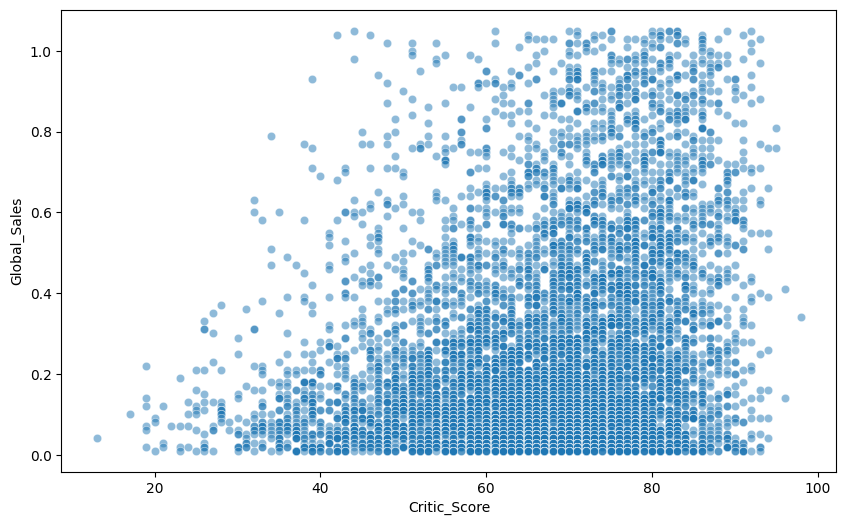

In [184]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Critic_Score", y="Global_Sales", alpha=0.5)

In [185]:
#tener una nota alta no garantiza tener muchas ventas. Al igual que tener una nota más floja tampoco implica vender menos.

###  1.2: Qué pesa más: comparar directamente qué correlaciona mejor con ventas, si la crítica profesional o la de usuarios

In [186]:
#ahora comparamos las ventas globales con el user score

correlacion_usuarios = df["Global_Sales"].corr(df["User_Score"])
print(f"La correlación entre la crítica y las ventas globales es: {correlacion_usuarios:.2f}")


La correlación entre la crítica y las ventas globales es: 0.10


<Axes: xlabel='User_Score', ylabel='Global_Sales'>

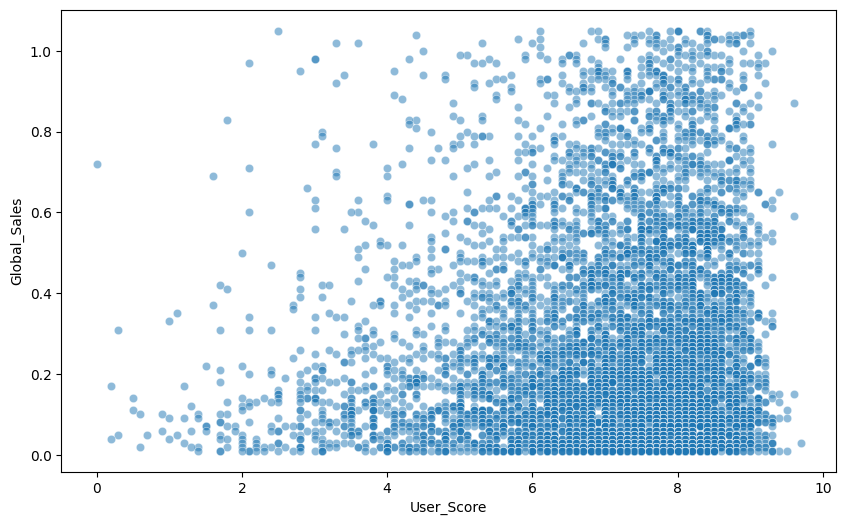

In [187]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="User_Score", y="Global_Sales", alpha=0.5)

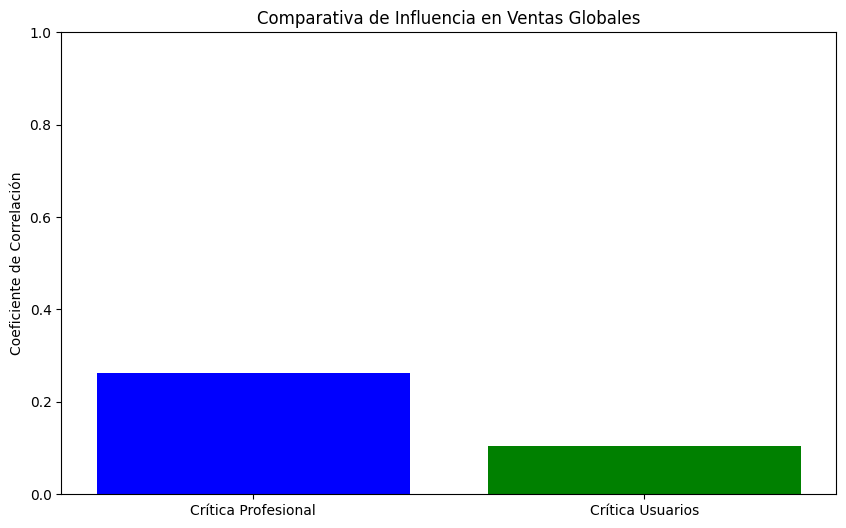

In [188]:
#la correlación es incluso menor que con la de los críticos.
#vamos a compararlas visualmetne

plt.figure(figsize=(10, 6))
labels = ["Crítica Profesional", "Crítica Usuarios"]
valores = [correlacion_criticos, correlacion_usuarios]
plt.bar(labels, valores, color= ["blue", "green"])
plt.ylabel("Coeficiente de Correlación")
plt.title("Comparativa de Influencia en Ventas Globales")
plt.ylim(0, 1) # El límite sería 1, que es una correlación directa
plt.show()

In [189]:
# De aquí se podría extraer alguna lectura:
#
# Hay gran cantidad de juegos que han vendido millones y que, sin embargo, tienen muy mala valoración.
# 
# Esto se puede deber al marketing, al peso de una saga o de una compañía, que puede influir en la compra 
# aunque el juego no guste luego.


### 1.3: Brecha crítico vs usuario: medir la diferencia Critic_Score vs User_Score


In [190]:
# vamos a comprobar si existe una correlación entre Critic Score y User Score
# el User Score está evaluado sobre 10, así que multiplicamos * 10 para que quede sobre 100

df["Score_dif"] = df["Critic_Score"] - (df["User_Score"] * 10)

print(df["Score_dif"].describe())

count    5920.000000
mean       -2.688176
std        12.830239
min       -62.000000
25%       -10.000000
50%        -3.000000
75%         4.000000
max        66.000000
Name: Score_dif, dtype: float64


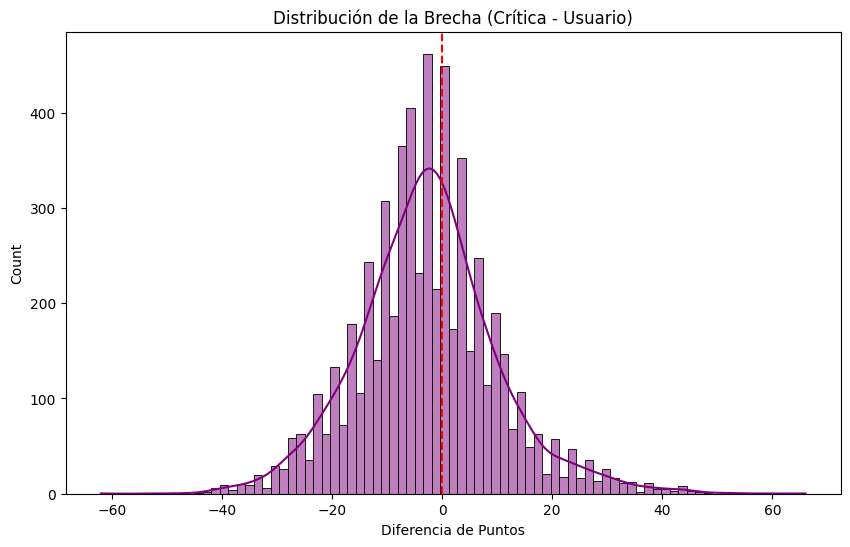

In [191]:
#vamos a visualizar la distribución de la diferencia entre uno y otro
plt.figure(figsize=(10, 6))
sns.histplot(df['Score_dif'], kde=True, color='purple')
plt.title('Distribución de la Brecha (Crítica - Usuario)')
plt.axvline(0, color='red', linestyle='--') #línea en 0 significa que ambos coinciden
plt.xlabel('Diferencia de Puntos')
plt.show()

In [192]:
#Con esta gráfica podemos ver que los usuarios tienden a ser ligerametne más generosos que los críticos puntuando

#La parte derecha de la cola puede ser muestra de juegos que gustaban a la prensa de la industria pero
#que no triunfaron entre el público

#Mientras que la cola que vemos a la izquierda muestra juegos de usuarios que puntuaron más alto que los críticos
#de ahí las diferencias tan grandes que vemos entre los -30 y los -10

#Hay que tener en cuenta que algunos de los outliers puede deberse a un número de críticas poco representativo

In [193]:
#Vamos a ver si en nuestros gráficos podemos tener algo de "ruido" debido a juegos con pocas valoraciones.
#Así que vamos a eliminar aquellos juegos que tengan <50 valoraciones para marcar un corte

df_nuevo = df[df["User_Count"] >= 50].copy()

print(f"Juegos antes del filtro: {len(df)}")
print(f"Juegos después del filtro (>= 50 votos): {len(df_nuevo)}")

#Volvemos a calcular la correlación para ver si ha cambiado
corr_filtrada = df_nuevo["Global_Sales"].corr(df_nuevo["Critic_Score"])
print(f"Nueva correlación Ventas - Crítica (Filtrada): {corr_filtrada:.2f}")

Juegos antes del filtro: 15437
Juegos después del filtro (>= 50 votos): 1702
Nueva correlación Ventas - Crítica (Filtrada): 0.17


In [194]:
df_nuevo["Score_dif"] = df_nuevo["Critic_Score"] - (df_nuevo["User_Score"] * 10)

print(df_nuevo["Score_dif"].describe())

count    1659.000000
mean        2.217601
std        11.728545
min       -41.000000
25%        -4.500000
50%         1.000000
75%         8.000000
max        59.000000
Name: Score_dif, dtype: float64


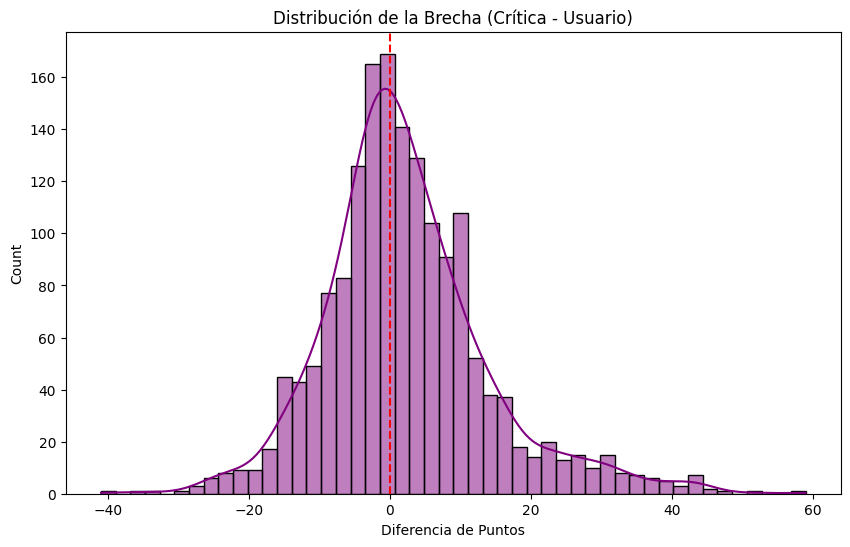

In [195]:
plt.figure(figsize=(10, 6))
sns.histplot(df_nuevo['Score_dif'], kde=True, color='purple')
plt.title('Distribución de la Brecha (Crítica - Usuario)')
plt.axvline(0, color='red', linestyle='--') #línea en 0 significa que ambos coinciden
plt.xlabel('Diferencia de Puntos')
plt.show()

In [196]:
#Como podemos comprobar, hay muchos juegos en la plataforma con menos de 50 reseñas, con lo cual esas valoraciones
#son poco representativas. Aunque 50 no es un volumen elevado, consideramos que podemos establecerlo como corte para hacernos
#una idea un poco más realista.

In [197]:
#Tras el filtrado vemos que si que hay una ligera desviación, pero no tan abultada ni desequilibrada como la que teníamos
#Como esos juegos con pocas reseñas nos generan ruido, no quedaremos con aquellos que tengan 50 o más para el resto del análisis

### 1.4: ¿Más reviews = más ventas?

In [198]:
#de nuevo hacemos un .corr para ver si existe correlación entre estas dos variables

corr_vol_criticos = df_nuevo["Global_Sales"].corr(df_nuevo["Critic_Count"]) #correlacion entre ventas y volumen de valoraciones por críticos
corr_vol_usuarios = df_nuevo["Global_Sales"].corr(df_nuevo["User_Count"]) #correlacion entre ventas y volumen de valoraciones por usuarios

print(f"Correlación Ventas - Volumen de Críticos: {corr_vol_criticos:.2f}")
print(f"Correlación Ventas - Volumen de Usuarios: {corr_vol_usuarios:.2f}")

Correlación Ventas - Volumen de Críticos: 0.39
Correlación Ventas - Volumen de Usuarios: 0.06


In [199]:
#existe cierta correlación entre el volumen de ventas y de críticas por parte de los críticos de la plataforma
#esto puede suceder debido a que una cobertura en medios, críticas, marketing... suele acompañar a las ventas
#aunque no es muy fuerte, se podría decir que existe cierta relación entre ambas variables

#Por otro lado, la correlación entre ventas y volumen de críticas de usuarios es prácticamente 0.

### 1.5 Evolución temporal: cómo evolucionan scores, counts y la brecha a lo largo de los años


In [200]:
tendencias_temporales = df_nuevo.groupby("Year_of_Release")[["Critic_Score", "User_Score", "Score_dif", "Critic_Count", "User_Count"]].mean()
tendencias_temporales

,Critic_Score,User_Score,Score_dif,Critic_Count,User_Count
Year_of_Release,,,,,
1988.0,64.000000,2.200000,42.000000,75.000000,4578.000000
1992.0,85.000000,8.300000,2.000000,44.000000,1862.000000
1996.0,86.000000,8.500000,1.000000,18.000000,3572.000000
1997.0,87.500000,8.900000,-1.500000,13.500000,293.000000
1998.0,88.400000,8.871429,-1.400000,15.600000,328.857143
1999.0,88.857143,8.722222,2.142857,17.428571,228.111111
2000.0,86.888889,8.777778,-0.888889,22.222222,342.000000
2001.0,81.157895,8.705263,-5.894737,19.736842,165.894737
2002.0,84.518519,8.640741,-1.888889,26.222222,231.000000


In [201]:
tendencias_temporales["User_Score_100"] = tendencias_temporales["User_Score"] * 10
tendencias_temporales

,Critic_Score,User_Score,Score_dif,Critic_Count,User_Count,User_Score_100
Year_of_Release,,,,,,
1988.0,64.000000,2.200000,42.000000,75.000000,4578.000000,22.000000
1992.0,85.000000,8.300000,2.000000,44.000000,1862.000000,83.000000
1996.0,86.000000,8.500000,1.000000,18.000000,3572.000000,85.000000
1997.0,87.500000,8.900000,-1.500000,13.500000,293.000000,89.000000
1998.0,88.400000,8.871429,-1.400000,15.600000,328.857143,88.714286
1999.0,88.857143,8.722222,2.142857,17.428571,228.111111,87.222222
2000.0,86.888889,8.777778,-0.888889,22.222222,342.000000,87.777778
2001.0,81.157895,8.705263,-5.894737,19.736842,165.894737,87.052632
2002.0,84.518519,8.640741,-1.888889,26.222222,231.000000,86.407407


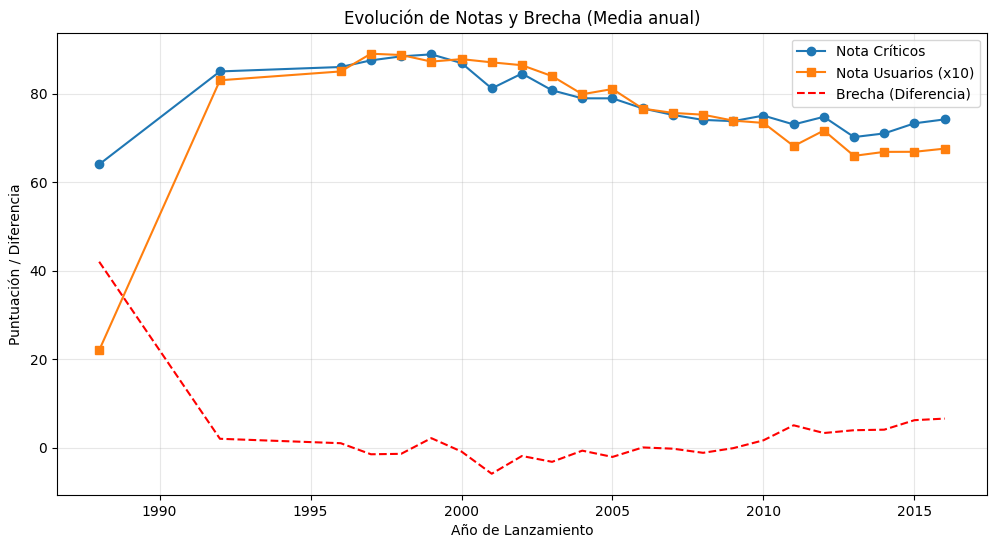

In [202]:
plt.figure(figsize=(12, 6))
plt.plot(tendencias_temporales.index, tendencias_temporales["Critic_Score"], label="Nota Críticos", marker="o")
plt.plot(tendencias_temporales.index, tendencias_temporales["User_Score_100"], label="Nota Usuarios (x10)", marker="s")
plt.plot(tendencias_temporales.index, tendencias_temporales["Score_dif"], label="Brecha (Diferencia)", linestyle="--", color="red")

plt.title("Evolución de Notas y Brecha (Media anual)")
plt.xlabel("Año de Lanzamiento")
plt.ylabel("Puntuación / Diferencia")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [203]:
#como el año 1988 ha dado un resultado extraño, vamos a comprobar si la muestra ha tenido algo que ver

#Comprobamos qué juegos de 1988 sobrevivieron al filtro de >50 reseñas
juegos_1988 = df_nuevo[df_nuevo["Year_of_Release"] == 1988][["Name", "User_Score", "User_Count"]]

print("Juegos que están haciendo la media de 1988:")
print(juegos_1988)

Juegos que están haciendo la media de 1988:
          Name  User_Score  User_Count
14713  SimCity         2.2      4578.0


In [204]:
#la media de ese año es debido a que solo contamos con la información de un juego en el año 1988. Concretamente el SimCity
#Vamos a descartar este año ya que un juego no es representativo y comenzaremos nuestro análisis desde el año 1995 para 
#responder a nuestra pregunta de las tendencias

In [205]:
# Reescribimos el código descartando los años <1995

df_grafico = df_nuevo[df_nuevo["Year_of_Release"] >= 1995]
tendencias = df_grafico.groupby("Year_of_Release")[["Critic_Score", "User_Score", "Score_dif"]].mean()
tendencias["User_Score_100"] = tendencias["User_Score"] * 10

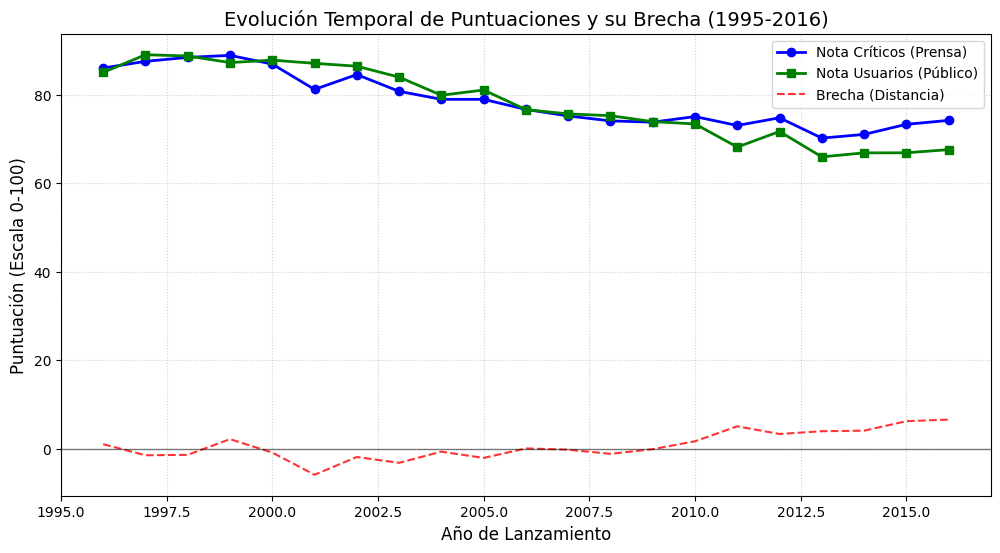

In [206]:
plt.figure(figsize=(12, 6))

plt.plot(tendencias.index, tendencias["Critic_Score"], label="Nota Críticos (Prensa)", color="blue", marker="o", linewidth=2)
plt.plot(tendencias.index, tendencias["User_Score_100"], label="Nota Usuarios (Público)", color="green", marker="s", linewidth=2)
plt.plot(tendencias.index, tendencias["Score_dif"], label="Brecha (Distancia)", color="red", linestyle="--", alpha=0.8)

# Añadimos una línea en el 0 para marcar el consenso perfecto
plt.axhline(0, color="black", linewidth=1, alpha=0.5)

# Personalización del gráfico
plt.title("Evolución Temporal de Puntuaciones y su Brecha (1995-2016)", fontsize=14)
plt.xlabel("Año de Lanzamiento", fontsize=12)
plt.ylabel("Puntuación (Escala 0-100)", fontsize=12)
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)

plt.show()

In [207]:
#Vemos que hay cierta tendencia bajista, además de que en la última década hay cierta brecha entre Users y Critics
#Esto también puede ser un indicador de que el mercado ha cambiado y no hay tanto consenso. Lo que respalda lo que 
#comentábamos anteriormente: los críticos y los usuarios no suelen estar de acuerdo

## Bloque 2

### 2.1: El Dominio del Mercado por Género


In [208]:
ventas_genero = df_nuevo.groupby("Genre")["Global_Sales"].sum().sort_values(ascending=False)
ventas_genero

/var/folders/nh/lx1tdtmn6f9dfr_3jl83894c0000gn/T/ipykernel_50941/635179661.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ventas_genero = df_nuevo.groupby("Genre")["Global_Sales"].sum().sort_values(ascending=False)


Genre
Action          175.72
Shooter         122.09
Role-Playing    101.22
Sports           52.68
Racing           33.04
Platform         30.54
Fighting         29.64
Strategy         22.98
Adventure        16.24
Simulation       15.32
Misc             14.85
Puzzle            3.75
Name: Global_Sales, dtype: float64

/var/folders/nh/lx1tdtmn6f9dfr_3jl83894c0000gn/T/ipykernel_50941/4187865673.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ventas_genero.values, y=ventas_genero.index, palette="rocket", order=ventas_genero.index)


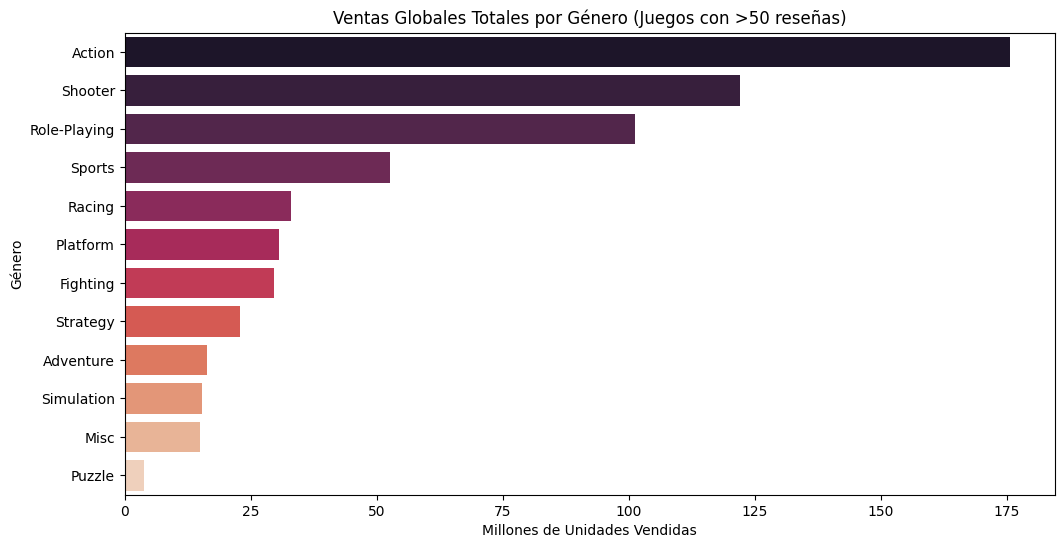

In [209]:
plt.figure(figsize=(12, 6))
sns.barplot(x=ventas_genero.values, y=ventas_genero.index, palette="rocket", order=ventas_genero.index)

plt.title("Ventas Globales Totales por Género (Juegos con >50 reseñas)")
plt.xlabel("Millones de Unidades Vendidas")
plt.ylabel("Género")
plt.show()

/var/folders/nh/lx1tdtmn6f9dfr_3jl83894c0000gn/T/ipykernel_50941/3724792166.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  eficiencia_genero = df_nuevo.groupby("Genre")["Global_Sales"].mean().sort_values(ascending=False)
/var/folders/nh/lx1tdtmn6f9dfr_3jl83894c0000gn/T/ipykernel_50941/3724792166.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=eficiencia_genero.values, y=eficiencia_genero.index, palette="mako",order=ventas_genero.index)


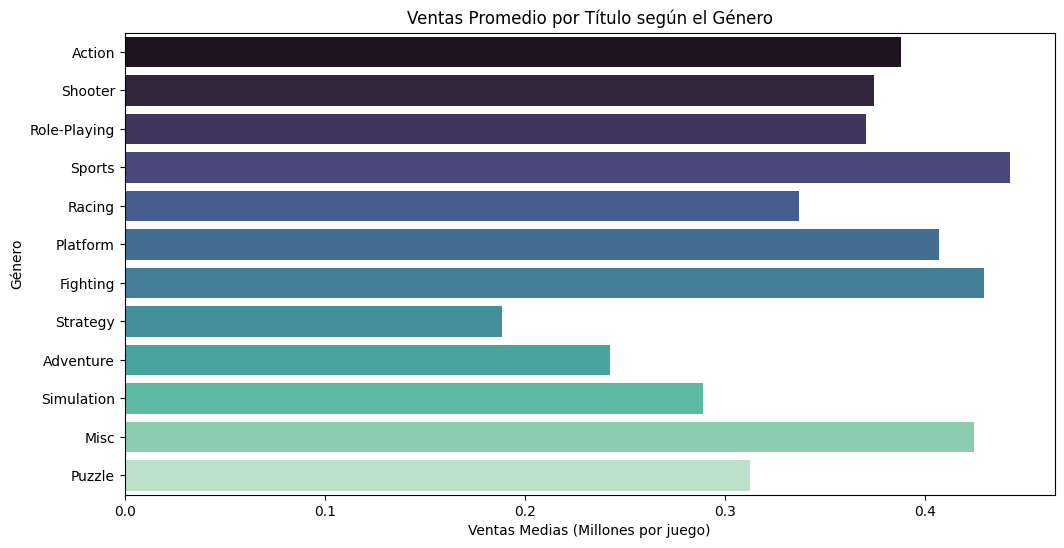

In [210]:
#para ver si es más cuestión de cantidad o de calidad por cada juego, vamos a si un género vende mucho por tener muchos títulos
# o si es por la calidad de los juegos 

eficiencia_genero = df_nuevo.groupby("Genre")["Global_Sales"].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=eficiencia_genero.values, y=eficiencia_genero.index, palette="mako",order=ventas_genero.index)

plt.title("Ventas Promedio por Título según el Género")
plt.xlabel("Ventas Medias (Millones por juego)")
plt.ylabel("Género")
plt.show()

In [211]:
#Con este último gráfico de barras podemos tener una imagen más representativa de lo que ocurre.
#Los juegos de Acción y Shooters obtienen una gran cantidad de ventas a pesar de que hayan salido más títulos 
#Se podría decir que el género más "eficiente" en relación a lanzamientos/ventas es Deportes.
#El género que menos éxito tiene por lanzamiento es el de juegos de Estrategia

In [212]:
#Ahora haremos este analisis pero por época para ver si cambia

def definir_epoca(year):
    if year <= 2000:
        return "1. Retro (Hasta 2000)"
    elif year <= 2010:
        return "2. Consolas Oro (2001-2010)" #época en la que se consagraron los juegos online y fenómenos como la Wii, GTA, Call of Duty
    else:
        return "3. Moderna (2011+)"
    
df_nuevo["Epoca"] = df_nuevo["Year_of_Release"].apply(definir_epoca)    
df_nuevo.head()



,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,...,Critic_Count,User_Score,User_Count,Rating,Critica_Profesional,Critica_Usuario,Tiene_Rating,Global_Sales_norm,Score_dif,Epoca
1971,LEGO The Lord of the Rings,PS3,2012.0,Action,Warner Bros. Interactive Entertainment,0.37,0.49,0.00,0.19,1.05,...,16.0,8.3,85.0,E10+,Sí,Sí,Sí,1.000000,-1.0,3. Moderna (2011+)
1972,EA Sports UFC,PS4,2014.0,Sports,Electronic Arts,0.46,0.41,0.01,0.18,1.05,...,57.0,6.1,280.0,T,Sí,Sí,Sí,1.000000,9.0,3. Moderna (2011+)
1977,Resident Evil: The Darkside Chronicles,Wii,2009.0,Action,Capcom,0.46,0.31,0.20,0.09,1.05,...,55.0,8.0,60.0,M,Sí,Sí,Sí,1.000000,-5.0,2. Consolas Oro (2001-2010)
1988,Forza Motorsport,X,2005.0,Racing,Microsoft Game Studios,0.52,0.51,0.00,0.02,1.05,...,73.0,7.6,214.0,E,Sí,Sí,Sí,1.000000,16.0,2. Consolas Oro (2001-2010)
1993,Legacy of Kain: Soul Reaver,PS,1999.0,Action,Eidos Interactive,0.58,0.40,0.00,0.07,1.04,...,17.0,9.0,133.0,T,Sí,Sí,Sí,0.990385,1.0,1. Retro (Hasta 2000)


/var/folders/nh/lx1tdtmn6f9dfr_3jl83894c0000gn/T/ipykernel_50941/2448092461.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  epoca_genero = df_nuevo.groupby(["Epoca", "Genre"])["Global_Sales"].sum().unstack().fillna(0)


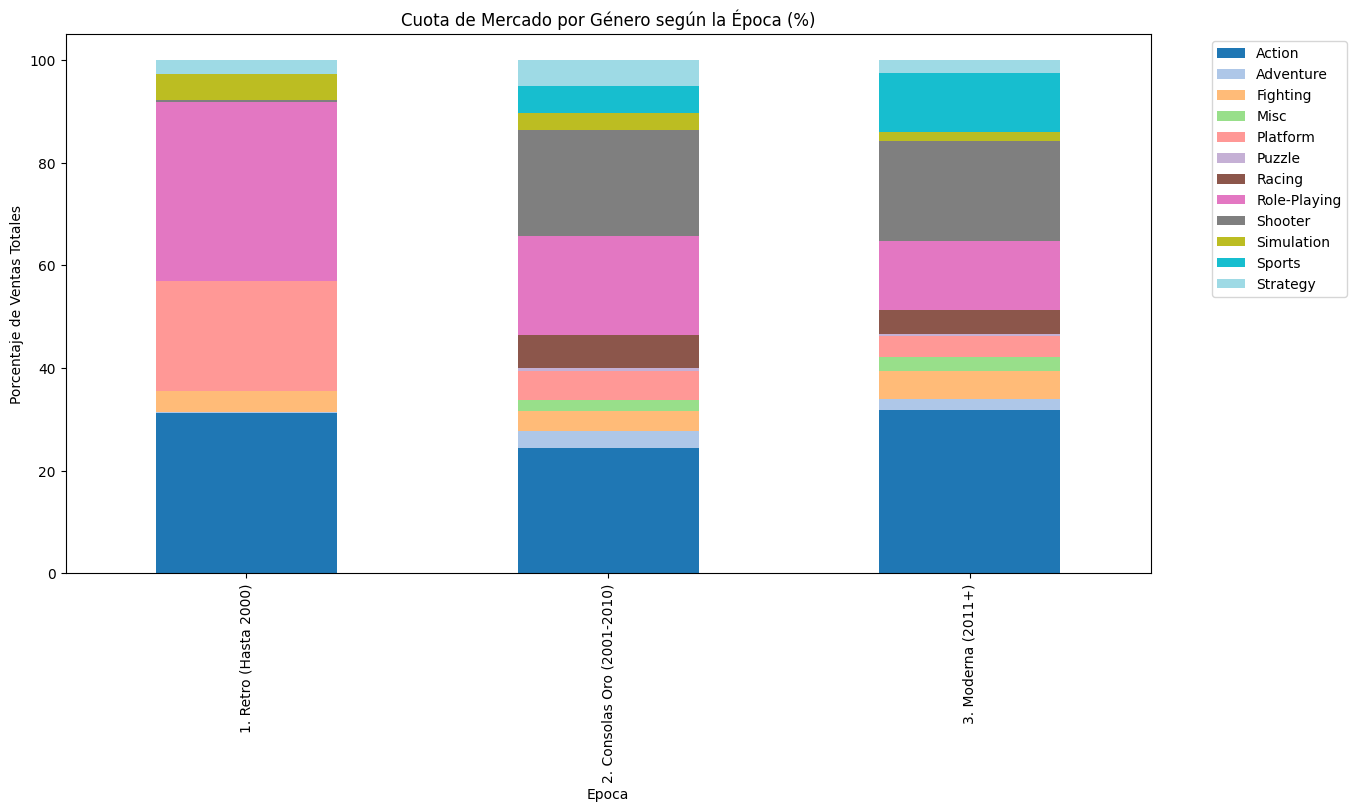

In [213]:
epoca_genero = df_nuevo.groupby(["Epoca", "Genre"])["Global_Sales"].sum().unstack().fillna(0)
epoca_perc = epoca_genero.div(epoca_genero.sum(axis=1), axis=0) * 100

epoca_perc.plot(kind="bar", stacked=True, figsize=(14, 7), colormap="tab20")
plt.title("Cuota de Mercado por Género según la Época (%)")
plt.ylabel("Porcentaje de Ventas Totales")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [214]:
#bemos que los Shooters (en gris) crecieron desde el año 2000, potencialmente debido a sagas como Call of Duty,
#pero también al surgimiento y normalización del juego online.

#También hay otras categorías que crecieron con el paso de los años, como las de Carreras o Deportes, posiblemente por la 
#evolución en gráficos y capacidad de procesamiento de las consolas, resultando en mayor calidad de videojuego

### 2.2: Ciclo de Vida de las Top Plataformas


In [220]:
top_5_plat = df_nuevo.groupby("Platform")["Global_Sales"].sum().nlargest(5).index.tolist()
top_5_plat

/var/folders/nh/lx1tdtmn6f9dfr_3jl83894c0000gn/T/ipykernel_50941/3714552238.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_5_plat = df_nuevo.groupby("Platform")["Global_Sales"].sum().nlargest(5).index.tolist()


['X360', 'PS3', 'PC', 'PS2', 'PS4']

/var/folders/nh/lx1tdtmn6f9dfr_3jl83894c0000gn/T/ipykernel_50941/2221129044.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  evolucion_plat = df_ciclo.groupby(["Year_of_Release", "Platform"])["Global_Sales"].sum().reset_index()


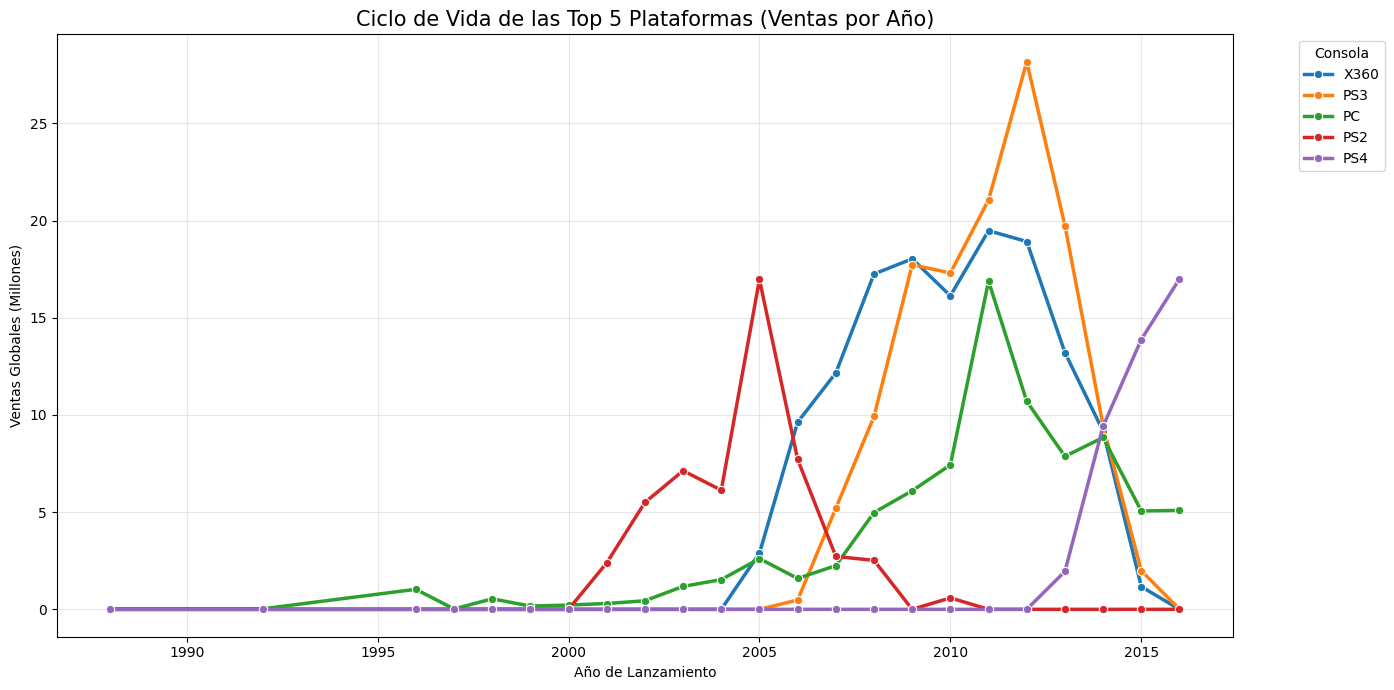

In [ ]:
if df_ciclo["Platform"].dtype == 'category':
    df_ciclo["Platform"] = df_ciclo["Platform"].cat.remove_unused_categories() #para eliminar las que no estan top 5

evolucion_plat = df_ciclo.groupby(["Year_of_Release", "Platform"])["Global_Sales"].sum().reset_index()


#creamos la gráfica
plt.figure(figsize=(14, 7))
sns.lineplot(
    data=evolucion_plat, 
    x="Year_of_Release", 
    y="Global_Sales", 
    hue="Platform", 
    hue_order=top_5_plat, 
    marker="o", 
    linewidth=2.5
)

plt.title("Ciclo de Vida de las Top 5 Plataformas (Ventas por Año)", fontsize=15)
plt.xlabel("Año de Lanzamiento")
plt.ylabel("Ventas Globales (Millones)")
plt.grid(True, alpha=0.3)
plt.legend(title="Consola", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
#Como vemos, la plaforma más exitosa ha sido PS3, alcanzando un pico de ventas de más de 25M
#Podemos ver que la mayoría de plataformas tienen un ciclo de vida marcado, menos el PC, que a pesaar de caer, se mantiene en el tiempo


### 2.3: Análisis de los Top 10 Publishers


In [228]:
top_publishers = df_nuevo.groupby("Publisher")["Global_Sales"].sum().nlargest(10)

top_publishers.info

<bound method Series.info of Publisher
Electronic Arts                87.23
Ubisoft                        54.80
Sony Computer Entertainment    36.86
Take-Two Interactive           36.18
Sega                           35.28
Activision                     33.21
Nintendo                       32.73
Namco Bandai Games             31.06
Square Enix                    28.01
Capcom                         25.99
Name: Global_Sales, dtype: float64>

/var/folders/nh/lx1tdtmn6f9dfr_3jl83894c0000gn/T/ipykernel_50941/649892305.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_publishers.values, y=top_publishers.index, palette="coolwarm")


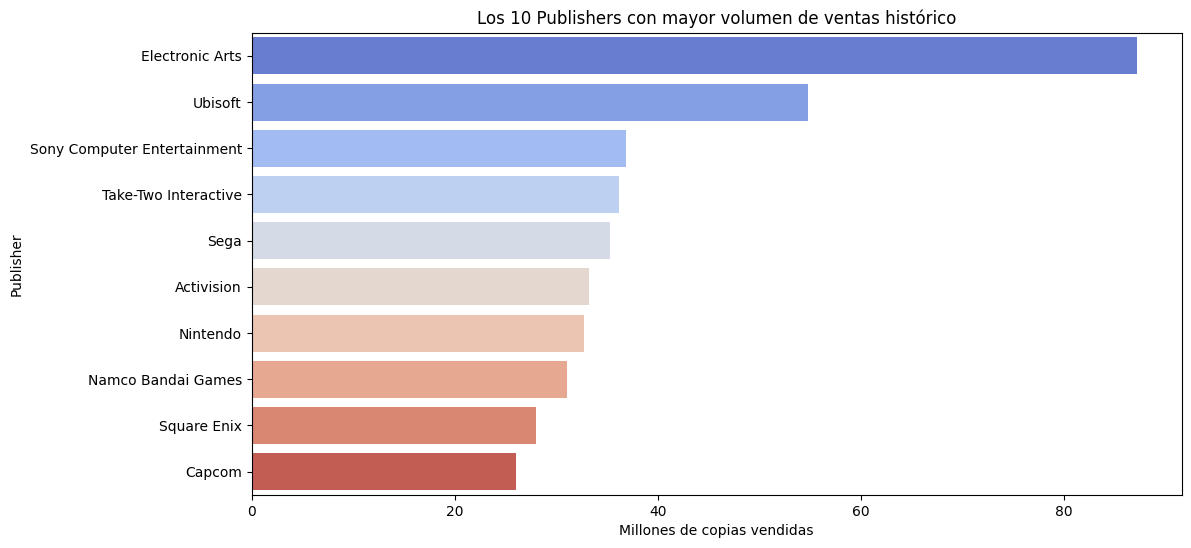

In [229]:
#vamos a visualizar el top 10

plt.figure(figsize=(12, 6))
sns.barplot(x=top_publishers.values, y=top_publishers.index, palette="coolwarm")
plt.title("Los 10 Publishers con mayor volumen de ventas histórico")
plt.xlabel("Millones de copias vendidas")
plt.show()

In [ ]:
#

### 2.4 Diferencias regionales: comparar NA/EU/JP/Other

### 2.4.1 Qué géneros/plataformas funcionan mejor en cada región

In [234]:
regiones = ["NA_Sales", "EU_Sales", "JP_Sales"]

print("LÍDERES POR REGIÓN")
for reg in regiones:
    top_gen = df_nuevo.groupby("Genre")[reg].sum().idxmax()
    top_plat = df_nuevo.groupby("Platform")[reg].sum().idxmax()
    print(f"En {reg}: El género líder es {top_gen} y la plataforma líder es {top_plat}")

LÍDERES POR REGIÓN
En NA_Sales: El género líder es Action y la plataforma líder es X360
En EU_Sales: El género líder es Action y la plataforma líder es PC
En JP_Sales: El género líder es Role-Playing y la plataforma líder es PS3


/var/folders/nh/lx1tdtmn6f9dfr_3jl83894c0000gn/T/ipykernel_50941/4049155433.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_gen = df_nuevo.groupby("Genre")[reg].sum().idxmax()
/var/folders/nh/lx1tdtmn6f9dfr_3jl83894c0000gn/T/ipykernel_50941/4049155433.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_plat = df_nuevo.groupby("Platform")[reg].sum().idxmax()
/var/folders/nh/lx1tdtmn6f9dfr_3jl83894c0000gn/T/ipykernel_50941/4049155433.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavi

### 2.4.2 ESRB y ventas: si el Rating ESRB afecta a las ventas a nivel global y por región, y si depende de otra variable

/var/folders/nh/lx1tdtmn6f9dfr_3jl83894c0000gn/T/ipykernel_50941/2171695395.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ventas_esrb_media.index, y=ventas_esrb_media.values, palette="Blues_r")


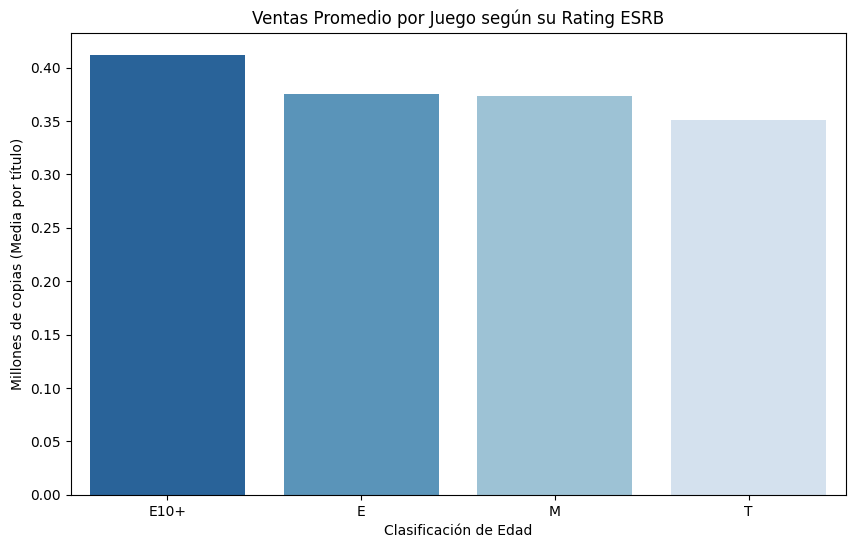

In [242]:
# calculamos la media de ventas por Rating
ventas_esrb_media = df_nuevo.groupby("Rating")["Global_Sales"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=ventas_esrb_media.index, y=ventas_esrb_media.values, palette="Blues_r")

plt.title("Ventas Promedio por Juego según su Rating ESRB")
plt.ylabel("Millones de copias (Media por título)")
plt.xlabel("Clasificación de Edad")
plt.show()

In [ ]:
#según nuestro dataset, no parece que haya una variación muy alta o que el Rating ESRB perjudique o beneficie en las ventas del juego

/var/folders/nh/lx1tdtmn6f9dfr_3jl83894c0000gn/T/ipykernel_50941/1075946738.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  esrb_genero_count = df_nuevo.pivot_table(index="Rating", columns="Genre", values="Name", aggfunc="count").fillna(0)


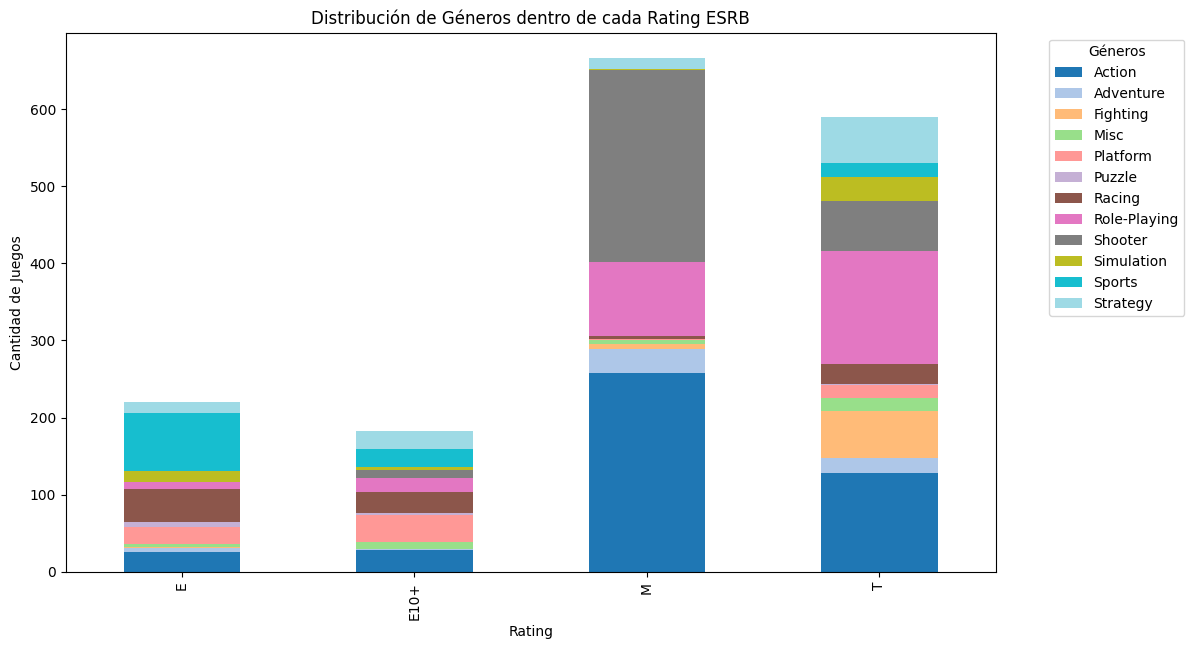

In [ ]:
#creamos una tabla cruzada de Género y Rating
esrb_genero_count = df_nuevo.pivot_table(index="Rating", columns="Genre", values="Name", aggfunc="count").fillna(0)
esrb_genero_count.plot(kind="bar", stacked=True, figsize=(12, 7), colormap="tab20")

plt.title("Distribución de Géneros dentro de cada Rating ESRB")
plt.ylabel("Cantidad de Juegos")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Géneros")
plt.show()

### 2.5 Top Sagas con más ventas